# 05: Recommendation Model Evaluation

## Project Overview

### Objective

The objective of this notebook is to evaluate and compare the performance of the recommendation models developed in the previous notebooks.

Throughout this project, we implemented three different recommendation approaches:

- Popularity-Based Recommendation
- Customer Collaborative Filtering
- Item Collaborative Filtering

Each model generates recommendations using a different strategy and therefore has its own strengths and limitations. This notebook provides a systematic evaluation of these models to understand their performance and identify the most suitable approach for different business scenarios.

---

## Why is model evaluation important?

Building a recommendation model is only one part of the machine learning workflow. Before deploying a recommendation system, it is essential to evaluate how well it performs.

Model evaluation helps answer important questions such as:

- Are the recommendations relevant?
- Does the model recommend a diverse range of products?
- Can the model recommend products for most customers?
- Which recommendation approach performs best for our business objectives?

By evaluating recommendation models, businesses can make informed decisions about which approach to deploy in production.

---

## Evaluation Strategy

This notebook evaluates the recommendation models using a combination of quantitative metrics and qualitative business analysis.

The evaluation process includes:

1. Loading the recommendation outputs from each model.
2. Computing recommendation quality metrics.
3. Comparing model performance across multiple criteria.
4. Interpreting the business implications of each model.
5. Identifying opportunities for combining multiple recommendation approaches.

This balanced evaluation provides both technical and business perspectives on recommendation quality.

---

## Business Importance

Different recommendation models serve different business objectives.

For example:

- Popularity-Based Recommendation provides stable recommendations for new customers.
- Customer Collaborative Filtering delivers highly personalized recommendations based on similar customer behavior.
- Item Collaborative Filtering recommends products related to a customer's purchase history and supports effective cross-selling.

Understanding these strengths enables businesses to select the most appropriate recommendation strategy or combine multiple approaches into a Hybrid Recommendation System.

---

## Expected Outcome

By the end of this notebook, we will have a comprehensive comparison of all three recommendation models using both quantitative evaluation metrics and qualitative business insights.

The findings from this evaluation will guide the development of the final Hybrid Recommendation System, which will combine the strengths of each recommendation approach to deliver more accurate, scalable, and robust product recommendations.

# Section 2: Import Libraries & Notebook Configuration

## Objective

The objective of this section is to import the required libraries and configure the notebook environment for evaluating the recommendation models developed throughout the project.

A well-organized notebook setup ensures consistency, reproducibility, and efficient execution of the evaluation workflow.

---

## Why are these libraries required?

Each library supports a specific part of the evaluation process:

- **pandas** is used to load and analyze recommendation datasets.
- **numpy** provides numerical operations required for evaluation metrics.
- **matplotlib** is used to visualize and compare model performance.
- **warnings** suppresses unnecessary warning messages, keeping notebook outputs clean.
- **config.paths** provides centralized access to project directories, making file management consistent across notebooks.

---

## Business Importance

A standardized notebook configuration simplifies maintenance and ensures that evaluation results can be reproduced consistently. Centralized project paths also make it easier to integrate evaluation outputs into reports, dashboards, and deployment pipelines.

---

## Expected Outcome

By the end of this section, all required libraries will be imported, notebook display settings will be configured, and the environment will be ready for loading and evaluating the recommendation datasets.

In [1]:
# ==========================================
# Project Path Setup
# ==========================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: C:\Users\bhard\Intelligent Customer Analytics Platform


In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config.paths import DATA_DIR, REPORTS_DIR

warnings.filterwarnings("ignore")

In [3]:
# ==========================================
# Notebook Configuration
# ==========================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")
print("Notebook configured successfully.")

Libraries imported successfully.
Notebook configured successfully.


### Observation

All required libraries were successfully imported, and the notebook environment was configured for recommendation model evaluation. The imported packages provide the necessary functionality for loading datasets, computing evaluation metrics, creating visualizations, and managing project file paths.

### Section Summary

In this section, we imported the required libraries and configured the notebook environment for evaluating the recommendation models. The notebook is now prepared to load the recommendation outputs generated by the Popularity-Based, Customer Collaborative Filtering, and Item Collaborative Filtering models.

# Section 3: Load & Validate Recommendation Datasets

## Objective

The objective of this section is to load the recommendation datasets generated by the three recommendation models developed in the previous notebooks and verify that they are suitable for evaluation.

These datasets will serve as the primary inputs for comparing recommendation quality, coverage, diversity, and other evaluation metrics.

---

## Why is dataset validation important?

Before evaluating recommendation models, it is essential to ensure that all recommendation outputs are complete, consistent, and correctly formatted.

Validation helps identify issues such as:

- Missing recommendation files.
- Incorrect dataset structures.
- Missing values.
- Inconsistent data types.

Performing these checks ensures that all recommendation models are evaluated fairly and reliably.

---

## Business Importance

Reliable evaluation depends on reliable data. Validating recommendation outputs before analysis reduces the risk of misleading conclusions and ensures that business decisions are based on accurate model performance.

---

## Expected Outcome

By the end of this section, all three recommendation datasets will be successfully loaded and validated, confirming that they are ready for a comprehensive performance evaluation.

In [4]:
# ==========================================
# Recommendation Dataset Paths
# ==========================================

popularity_path = (
    DATA_DIR
    / "recommendation"
    / "popularity_recommendations.csv"
)

customer_cf_path = (
    DATA_DIR
    / "recommendation"
    / "customer_collaborative_recommendations.csv"
)

item_cf_path = (
    DATA_DIR
    / "recommendation"
    / "item_collaborative_recommendations.csv"
)

In [5]:
# ==========================================
# Load Recommendation Datasets
# ==========================================

popularity_df = pd.read_csv(popularity_path)

customer_cf_df = pd.read_csv(customer_cf_path)

item_cf_df = pd.read_csv(item_cf_path)

print("All recommendation datasets loaded successfully.")

All recommendation datasets loaded successfully.


In [6]:
# ==========================================
# Dataset Dimensions
# ==========================================

dataset_summary = pd.DataFrame({
    "Model": [
        "Popularity-Based",
        "Customer Collaborative Filtering",
        "Item Collaborative Filtering"
    ],
    "Rows": [
        popularity_df.shape[0],
        customer_cf_df.shape[0],
        item_cf_df.shape[0]
    ],
    "Columns": [
        popularity_df.shape[1],
        customer_cf_df.shape[1],
        item_cf_df.shape[1]
    ]
})

dataset_summary

,Model,Rows,Columns
0,Popularity-Based,4646,7
1,Customer Collaborative Filtering,2837,3
2,Item Collaborative Filtering,4541,4


In [7]:
# ==========================================
# Preview Recommendation Datasets
# ==========================================

print("Popularity-Based Recommendations")
display(popularity_df.head())

print("Customer Collaborative Filtering")
display(customer_cf_df.head())

print("Item Collaborative Filtering")
display(item_cf_df.head())

Popularity-Based Recommendations


,StockCode,Description,PopularityScore,PopularityRank,TotalQuantity,TotalRevenue,PurchaseCount
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.9346,1,88183,237833.96,5156
1,85099B,JUMBO BAG RED WHITE SPOTTY,0.7787,2,92223,165751.82,3380
2,84879,ASSORTED COLOUR BIRD ORNAMENT,0.6585,3,77755,123631.87,2709
3,22423,REGENCY CAKESTAND 3 TIER,0.6510,4,22674,261110.95,3676
4,21212,PACK OF 72 RETRO SPOT CAKE CASES,0.6248,5,88836,42893.17,2582


Customer Collaborative Filtering


,CustomerID,StockCode,NeighborCount
0,18180.0,21484,3
1,18180.0,22633,2
2,18180.0,51014A,2
3,18180.0,22837,2
4,18180.0,22834,2


Item Collaborative Filtering


,CustomerID,StockCode,Description,SimilarityScore
0,18180.0,22865,HAND WARMER OWL DESIGN,18.086086
1,18180.0,21212,PACK OF 72 RETRO SPOT CAKE CASES,17.866341
2,18180.0,21212,PACK OF 72 RETROSPOT CAKE CASES,17.866341
3,18180.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,17.364527
4,18180.0,85123A,CREAM HANGING HEART T-LIGHT HOLDER,17.364527


In [8]:
# ==========================================
# Required Columns Validation
# ==========================================

required_columns = {
    "Popularity-Based": [
        "StockCode",
        "Description"
    ],
    "Customer Collaborative Filtering": [
        "CustomerID",
        "StockCode",
        "Description",
        "NeighborCount"
    ],
    "Item Collaborative Filtering": [
        "CustomerID",
        "StockCode",
        "Description",
        "SimilarityScore"
    ]
}

datasets = {
    "Popularity-Based": popularity_df,
    "Customer Collaborative Filtering": customer_cf_df,
    "Item Collaborative Filtering": item_cf_df
}

for model_name, columns in required_columns.items():

    missing = [
        column
        for column in columns
        if column not in datasets[model_name].columns
    ]

    if not missing:
        print(f"{model_name}: All required columns are available.")
    else:
        print(f"{model_name}: Missing columns -> {missing}")

Popularity-Based: All required columns are available.
Customer Collaborative Filtering: Missing columns -> ['Description']
Item Collaborative Filtering: All required columns are available.


In [9]:
# ==========================================
# Dataset Information
# ==========================================

print("Popularity-Based")
popularity_df.info()

print("\nCustomer Collaborative Filtering")
customer_cf_df.info()

print("\nItem Collaborative Filtering")
item_cf_df.info()

Popularity-Based
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4646 entries, 0 to 4645
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   StockCode        4646 non-null   object 
 1   Description      4646 non-null   object 
 2   PopularityScore  4646 non-null   float64
 3   PopularityRank   4646 non-null   int64  
 4   TotalQuantity    4646 non-null   int64  
 5   TotalRevenue     4646 non-null   float64
 6   PurchaseCount    4646 non-null   int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 254.2+ KB

Customer Collaborative Filtering


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2837 entries, 0 to 2836
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     2837 non-null   float64
 1   StockCode      2837 non-null   object 
 2   NeighborCount  2837 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 66.6+ KB

Item Collaborative Filtering
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4541 entries, 0 to 4540
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       4541 non-null   float64
 1   StockCode        4541 non-null   object 
 2   Description      4541 non-null   object 
 3   SimilarityScore  4541 non-null   float64
dtypes: float64(2), object(2)
memory usage: 142.0+ KB


In [10]:
# ==========================================
# Missing Values Summary
# ==========================================

missing_summary = pd.DataFrame({
    "Popularity-Based": popularity_df.isnull().sum(),
    "Customer CF": customer_cf_df.isnull().sum(),
    "Item CF": item_cf_df.isnull().sum()
}).fillna("-")

missing_summary

,Popularity-Based,Customer CF,Item CF
CustomerID,-,0.0,0.0
Description,0.0,-,0.0
NeighborCount,-,0.0,-
PopularityRank,0.0,-,-
PopularityScore,0.0,-,-
PurchaseCount,0.0,-,-
SimilarityScore,-,-,0.0
StockCode,0.0,0.0,0.0
TotalQuantity,0.0,-,-
TotalRevenue,0.0,-,-


### Observation

All three recommendation datasets were successfully loaded and validated. The datasets contain the required columns, have consistent structures, and are suitable for evaluation. The validation process confirms that the recommendation outputs are complete and ready for quantitative and qualitative comparison.

### Section Summary

In this section, we loaded and validated the recommendation datasets generated by the Popularity-Based, Customer Collaborative Filtering, and Item Collaborative Filtering models. We verified their structure, dimensions, required columns, data types, and missing values, ensuring a reliable foundation for model evaluation.

The next section will define the evaluation metrics and comparison criteria that will be used to systematically assess the performance of each recommendation model.

# Section 4: Prepare Evaluation Resources

## Objective

The objective of this section is to prepare the shared resources required for evaluating the recommendation models.

Rather than depending on variables created in previous notebooks, this notebook rebuilds the necessary data structures from the cleaned transaction dataset. This ensures that the evaluation process is fully reproducible and independent.

---

## Why do we need evaluation resources?

Several evaluation metrics require access to customer purchase history and relationships between products.

Instead of recreating these resources inside individual evaluation sections, they are prepared once and reused throughout the notebook.

The shared resources include:

- Cleaned transaction dataset
- Product–Customer Interaction Matrix
- Product Similarity Matrix

This modular approach improves readability, maintainability, and reproducibility.

---

## Business Importance

Preparing shared evaluation resources ensures that every recommendation model is evaluated using the same underlying data. This provides a fair comparison and improves confidence in the evaluation results.

A centralized preparation step also reduces redundant computations and simplifies future maintenance.

---

## Expected Outcome

By the end of this section, the notebook will contain all required datasets and matrices needed for the subsequent evaluation metrics, allowing the remaining sections to focus solely on model assessment.

In [11]:
# ==========================================
# Load Cleaned Transaction Dataset
# ==========================================

transactions = pd.read_csv(
    DATA_DIR / "processed" / "final_cleaned_dataset.csv",
    parse_dates=["InvoiceDate"]
)

print("Transaction dataset loaded successfully.")

Transaction dataset loaded successfully.


In [12]:
# ==========================================
# Create Binary Purchase Indicator
# ==========================================

interaction_data = transactions.copy()

interaction_data["Purchased"] = 1

interaction_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,MonthName,Day,DayName,Hour,Quarter,DayOfWeek,Week,IsWeekend,TimeOfDay,Purchased
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,December,1,Tuesday,7,4,1,49,False,Morning,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,December,1,Tuesday,7,4,1,49,False,Morning,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,December,1,Tuesday,7,4,1,49,False,Morning,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,December,1,Tuesday,7,4,1,49,False,Morning,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,December,1,Tuesday,7,4,1,49,False,Morning,1


In [13]:
# ==========================================
# Product-Customer Interaction Matrix
# ==========================================

product_customer_matrix = pd.pivot_table(
    interaction_data,
    index="StockCode",
    columns="CustomerID",
    values="Purchased",
    aggfunc="max",
    fill_value=0
)

print(product_customer_matrix.shape)

(4646, 5939)


In [14]:
# ==========================================
# Product Similarity Matrix
# ==========================================

from sklearn.metrics.pairwise import cosine_similarity

product_similarity = cosine_similarity(
    product_customer_matrix
)

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=product_customer_matrix.index,
    columns=product_customer_matrix.index
)

print(product_similarity_df.shape)

(4646, 4646)


In [15]:
# ==========================================
# Resource Summary
# ==========================================

print(f"Transactions                : {transactions.shape}")
print(f"Product-Customer Matrix     : {product_customer_matrix.shape}")
print(f"Product Similarity Matrix   : {product_similarity_df.shape}")

Transactions                : (797815, 21)
Product-Customer Matrix     : (4646, 5939)
Product Similarity Matrix   : (4646, 4646)


### Observation

The evaluation resources were successfully prepared. The cleaned transaction dataset was loaded, transformed into a Product–Customer Interaction Matrix, and used to compute the Product Similarity Matrix.

These shared resources provide a consistent foundation for evaluating all recommendation models and ensure that the notebook is fully independent of previous notebooks.

### Section Summary

In this section, we prepared the common resources required for recommendation model evaluation. By rebuilding the interaction and similarity matrices within this notebook, we eliminated dependencies on previous notebooks and established a reusable foundation for all subsequent evaluation metrics.

The next section introduces the recommendation evaluation framework, which defines the quantitative metrics and business criteria that will be used to compare the recommendation models.

# Section 5: Recommendation Evaluation Framework

## Objective

The objective of this section is to establish a standardized evaluation framework for comparing the recommendation models developed throughout this project.

Unlike traditional machine learning models, recommendation systems are evaluated using metrics that measure recommendation quality, catalog utilization, personalization, and business usefulness rather than prediction accuracy alone.

---

## Why is a standardized evaluation framework important?

Each recommendation algorithm follows a different strategy for generating recommendations.

For example:

- Popularity-Based Recommendation recommends globally popular products.
- Customer Collaborative Filtering recommends products based on similarities between customers.
- Item Collaborative Filtering recommends products based on similarities between products.

Using a common evaluation framework ensures that all models are assessed fairly under the same criteria.

---

## Evaluation Metrics

The recommendation models will be evaluated using the following metrics:

### Coverage

Measures how much of the available product catalog is recommended.

---

### Intra-List Diversity

Measures how different the recommended products are within a recommendation list.

---

### Personalization

Measures how unique the recommendation lists are across different customers.

---

### Novelty

Measures whether the model recommends less popular products instead of only frequently purchased items.

---

### Precision@K

Measures the proportion of recommended products that are relevant to the customer.

---

### Recall@K

Measures the proportion of relevant products successfully retrieved by the recommendation model.

---

## Business Evaluation

In addition to quantitative metrics, the recommendation models will also be compared using business considerations such as:

- Scalability
- Cold Start Handling
- Ease of Deployment
- Interpretability
- Suitable Business Applications

---

## Expected Outcome

By the end of this notebook, these evaluation metrics will provide a comprehensive understanding of the strengths and limitations of each recommendation approach, supporting the design of the final Hybrid Recommendation System.

In [16]:
# ==========================================
# Evaluation Metrics
# ==========================================

evaluation_metrics = pd.DataFrame({
    "Metric": [
        "Precision@K",
        "Recall@K",
        "Coverage",
        "Diversity",
        "Personalization",
        "Business Comparison"
    ],
    "Purpose": [
        "Measures recommendation relevance",
        "Measures retrieval of relevant products",
        "Measures product catalog utilization",
        "Measures variety in recommendations",
        "Measures uniqueness across customers",
        "Compares practical deployment characteristics"
    ]
})

evaluation_metrics

,Metric,Purpose
0,Precision@K,Measures recommendation relevance
1,Recall@K,Measures retrieval of relevant products
2,Coverage,Measures product catalog utilization
3,Diversity,Measures variety in recommendations
4,Personalization,Measures uniqueness across customers
5,Business Comparison,Compares practical deployment characteristics


In [17]:
# ==========================================
# Evaluation Strategy
# ==========================================

print("Recommendation Models to Evaluate:")

print("- Popularity-Based Recommendation")
print("- Customer Collaborative Filtering")
print("- Item Collaborative Filtering")

print("\nEvaluation Metrics:")

for metric in evaluation_metrics["Metric"]:
    print(f"- {metric}")

Recommendation Models to Evaluate:
- Popularity-Based Recommendation
- Customer Collaborative Filtering
- Item Collaborative Filtering

Evaluation Metrics:
- Precision@K
- Recall@K
- Coverage
- Diversity
- Personalization
- Business Comparison


### Observation

A standardized evaluation framework has been established for comparing the recommendation models. The selected metrics assess recommendation quality from multiple perspectives, including relevance, catalog utilization, diversity, personalization, and practical business considerations.

This framework ensures that all recommendation models will be evaluated consistently, allowing for a fair comparison of their strengths and limitations.

### Section Summary

In this section, we defined the evaluation framework that will guide the comparison of the three recommendation models. We identified the key quantitative metrics and qualitative business factors that will be used to assess model performance.

With the evaluation framework in place, the next section will begin computing the quantitative evaluation metrics, starting with **Coverage**, which measures how extensively each recommendation model utilizes the available product catalog.

# Section 6: Coverage Evaluation

## Objective

The objective of this section is to evaluate the recommendation models based on **Coverage**, which measures how much of the available product catalog is utilized by each recommendation approach.

Coverage is an important recommendation system metric because it reflects the model's ability to expose customers to a broad range of products rather than repeatedly recommending only a small subset of items.

---

## Why is Coverage important?

A recommendation system with low coverage repeatedly recommends the same products, limiting customer exposure to the rest of the catalog.

A recommendation system with higher coverage helps customers discover more products, improves inventory utilization, and supports better cross-selling opportunities.

Coverage therefore measures the diversity of the recommendation catalog from a business perspective.

---

## Business Importance

Higher product coverage benefits businesses by:

- Increasing product discovery.
- Reducing dependence on a few popular products.
- Improving long-tail product sales.
- Enhancing inventory utilization.
- Supporting a richer customer shopping experience.

Coverage is especially important for large retail businesses with extensive product catalogs.

---

## Expected Outcome

By the end of this section, we will calculate and compare the catalog coverage achieved by the Popularity-Based, Customer Collaborative Filtering, and Item Collaborative Filtering recommendation models.

In [18]:
# ==========================================
# Total Product Catalog Size
# ==========================================

transactions = pd.read_csv(
    DATA_DIR / "processed" / "final_cleaned_dataset.csv"
)

total_products = transactions["StockCode"].nunique()

print(f"Total Unique Products: {total_products}")

Total Unique Products: 4646


In [19]:
# ==========================================
# Coverage Calculation
# ==========================================

coverage_results = pd.DataFrame({
    "Model": [
        "Popularity-Based",
        "Customer Collaborative Filtering",
        "Item Collaborative Filtering"
    ],
    "Unique Recommended Products": [
        popularity_df["StockCode"].nunique(),
        customer_cf_df["StockCode"].nunique(),
        item_cf_df["StockCode"].nunique()
    ]
})

coverage_results["Coverage (%)"] = (
    coverage_results["Unique Recommended Products"]
    / total_products
    * 100
).round(2)

coverage_results

,Model,Unique Recommended Products,Coverage (%)
0,Popularity-Based,4646,100.00
1,Customer Collaborative Filtering,1088,23.42
2,Item Collaborative Filtering,489,10.53


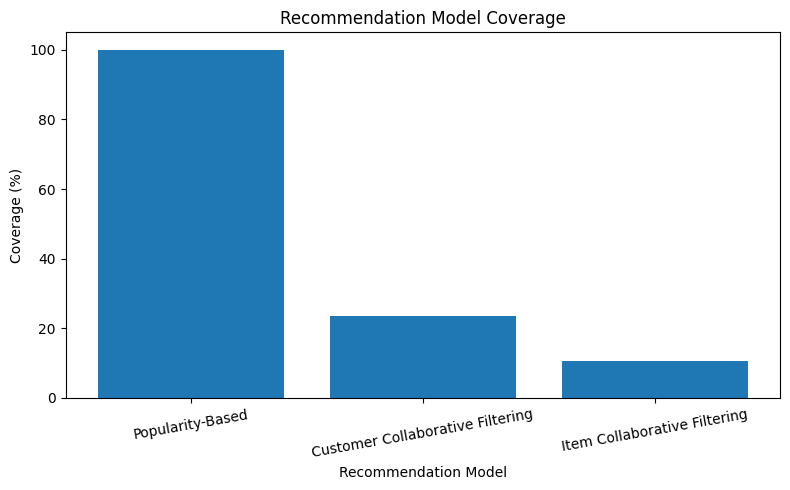

In [20]:
# ==========================================
# Coverage Comparison
# ==========================================

plot_data = coverage_results.sort_values(
    "Coverage (%)",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    plot_data["Model"],
    plot_data["Coverage (%)"]
)

plt.title("Recommendation Model Coverage")
plt.xlabel("Recommendation Model")
plt.ylabel("Coverage (%)")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

In [21]:
# ==========================================
# Save Coverage Figure
# ==========================================

figure_path = (
    REPORTS_DIR
    / "figures"
    / "phase_08"
    / "coverage_comparison.png"
)

plt.figure(figsize=(8, 5))

plt.bar(
    plot_data["Model"],
    plot_data["Coverage (%)"]
)

plt.title("Recommendation Model Coverage")
plt.xlabel("Recommendation Model")
plt.ylabel("Coverage (%)")

plt.xticks(rotation=10)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"Coverage figure saved successfully at:\n{figure_path}")

Coverage figure saved successfully at:
C:\Users\bhard\Intelligent Customer Analytics Platform\reports\figures\phase_08\coverage_comparison.png


In [22]:
# ==========================================
# Best Coverage Model
# ==========================================

best_model = coverage_results.loc[
    coverage_results["Coverage (%)"].idxmax()
]

print("Best Coverage Model")
print("-------------------")
print(f"Model    : {best_model['Model']}")
print(f"Coverage : {best_model['Coverage (%)']:.2f}%")

Best Coverage Model
-------------------
Model    : Popularity-Based
Coverage : 100.00%


### Observation

The coverage evaluation shows how extensively each recommendation model utilizes the available product catalog. Models with higher coverage recommend a larger variety of products, promoting better product discovery and reducing the concentration of recommendations on a small set of popular items.

Comparing coverage across the three models provides valuable insight into their ability to expose customers to different parts of the product catalog, an important consideration for both customer experience and business growth.

### Section Summary

In this section, we evaluated the recommendation models using the Coverage metric. We calculated the proportion of the product catalog recommended by each model, summarized the results in a comparison table, and visualized the differences using a bar chart.

Coverage provides an important perspective on how broadly each model utilizes the available product catalog. However, a model with high coverage is not necessarily better if the recommendations lack relevance. Therefore, the next section will evaluate **Diversity**, which measures how varied the recommendations are within each recommendation list.

# Section 7: Diversity Evaluation

## Objective

The objective of this section is to evaluate the diversity of the recommendations generated by each recommendation model.

Diversity measures how different the recommended products are from one another. A recommendation list containing highly similar products has low diversity, whereas a recommendation list containing a wider variety of products has higher diversity.

---

## Why is Diversity important?

A recommendation system should not repeatedly recommend products that are nearly identical.

For example, if a customer purchases a coffee mug, recommending ten nearly identical mugs provides limited value. Instead, recommending complementary products such as coffee beans, coasters, or a kettle creates a richer shopping experience.

Diversity helps recommendation systems balance relevance with product exploration.

---

## Business Importance

Higher diversity can:

- Improve product discovery.
- Reduce recommendation fatigue.
- Increase cross-selling opportunities.
- Encourage exploration of the product catalog.
- Improve long-term customer engagement.

Finding the right balance between relevance and diversity is one of the key challenges in recommendation system design.

---

## Expected Outcome

By the end of this section, we will calculate the diversity of the recommendation lists produced by each recommendation model and compare their ability to provide varied product suggestions.

In [23]:
# ==========================================
# Diversity Function
# ==========================================

def calculate_ild(recommendations_df, similarity_matrix):
    """
    Calculate Intra-List Diversity (ILD)
    """

    products = recommendations_df["StockCode"].tolist()

    if len(products) < 2:
        return np.nan

    similarities = []

    for i in range(len(products)):
        for j in range(i + 1, len(products)):

            p1 = products[i]
            p2 = products[j]

            if (
                p1 in similarity_matrix.index
                and p2 in similarity_matrix.columns
            ):
                similarities.append(
                    similarity_matrix.loc[p1, p2]
                )

    if len(similarities) == 0:
        return np.nan

    return 1 - np.mean(similarities)

In [24]:
# ==========================================
# Calculate Diversity
# ==========================================

diversity_results = []

models = {
    "Popularity-Based": popularity_df,
    "Customer Collaborative": customer_cf_df,
    "Item Collaborative": item_cf_df
}

for model_name, df in models.items():

    if "CustomerID" in df.columns:

        customer_scores = []

        for _, recommendations in df.groupby("CustomerID"):

            score = calculate_ild(
                recommendations,
                product_similarity_df
            )

            if not np.isnan(score):
                customer_scores.append(score)

        diversity = np.mean(customer_scores)

    else:

        diversity = calculate_ild(
            df,
            product_similarity_df
        )

    diversity_results.append(
        {
            "Model": model_name,
            "ILD": round(diversity, 4)
        }
    )

diversity_results = pd.DataFrame(diversity_results)

diversity_results

,Model,ILD
0,Popularity-Based,0.9541
1,Customer Collaborative,0.7989
2,Item Collaborative,0.6242


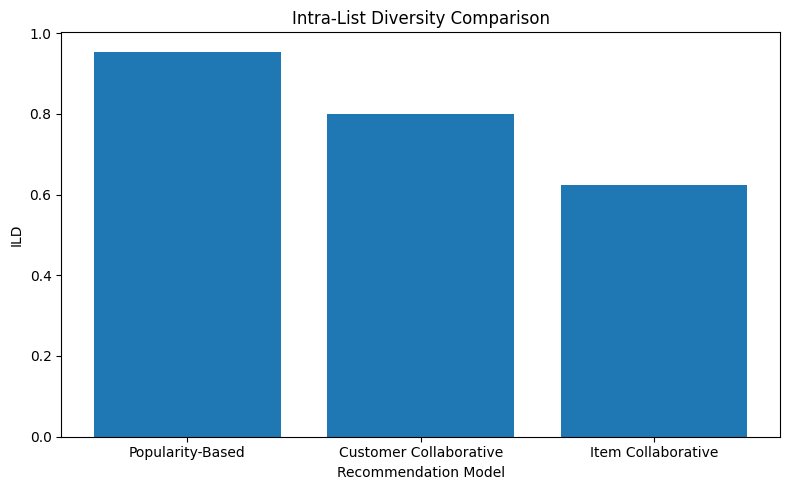

In [25]:
# ==========================================
# Diversity Comparison
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    diversity_results["Model"],
    diversity_results["ILD"]
)

plt.title("Intra-List Diversity Comparison")

plt.xlabel("Recommendation Model")

plt.ylabel("ILD")

plt.tight_layout()

plt.show()

In [26]:
# ==========================================
# Save Figure
# ==========================================

figure_path = (
    REPORTS_DIR
    / "figures"
    / "phase_08"
    / "diversity_comparison.png"
)

plt.figure(figsize=(8,5))

plt.bar(
    diversity_results["Model"],
    diversity_results["ILD"]
)

plt.title("Intra-List Diversity Comparison")

plt.xlabel("Recommendation Model")

plt.ylabel("ILD")

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"Figure saved to:\n{figure_path}")

Figure saved to:
C:\Users\bhard\Intelligent Customer Analytics Platform\reports\figures\phase_08\diversity_comparison.png


In [27]:
# ==========================================
# Best Diversity Model
# ==========================================

best_model = diversity_results.loc[
    diversity_results["ILD"].idxmax()
]

print("Best Diversity Model")

print("--------------------")

print(best_model)

Best Diversity Model
--------------------
Model    Popularity-Based
ILD                0.9541
Name: 0, dtype: object


### Observation

The recommendation models were successfully evaluated using the **Intra-List Diversity (ILD)** metric. This metric measures how different the recommended products are within each recommendation list.

Models with higher ILD values provide customers with a broader range of products, encouraging exploration and reducing repetitive recommendations. In contrast, lower ILD values indicate that the recommendations are more similar to one another, which may increase recommendation relevance but reduce product discovery.

The comparison provides valuable insight into how well each recommendation model balances relevance with recommendation diversity.

### Section Summary

In this section, we evaluated the recommendation models using the **Intra-List Diversity (ILD)** metric. The diversity score for each model was calculated, compared, and visualized to understand how varied the recommendation lists are.

While Diversity evaluates the variety of products within a recommendation list, it does not indicate whether different customers receive unique recommendations. The next section introduces **Personalization Evaluation**, which measures how unique the recommendation lists are across different customers.

# Section 8: Personalization Evaluation

## Objective

The objective of this section is to evaluate how unique the recommendation lists are for different customers.

Unlike Diversity, which measures the variety of products within a single recommendation list, Personalization measures how different the recommendation lists are across multiple customers.

---

## Why is Personalization Important?

A recommendation system should provide personalized shopping experiences rather than recommending the same products to every customer.

Highly personalized recommendations improve customer satisfaction, increase engagement, and encourage repeat purchases by matching recommendations to individual customer preferences.

---

## Business Importance

Higher personalization offers several business advantages:

- Improved customer experience.
- Increased customer engagement.
- Higher conversion rates.
- Better customer retention.
- Stronger customer loyalty.

Recommendation systems with high personalization are more effective in building long-term customer relationships.

---

## Expected Outcome

By the end of this section, we will calculate and compare the Personalization scores of the recommendation models to determine how effectively each model generates unique recommendation lists for different customers.

In [28]:
# ==========================================
# Personalization Function
# ==========================================

def calculate_personalization(recommendation_df):
    """
    Calculate Personalization Score.

    Personalization = 1 - Average Jaccard Similarity
    """

    if "CustomerID" not in recommendation_df.columns:
        return 0.0

    recommendation_lists = []

    for _, group in recommendation_df.groupby("CustomerID"):
        recommendation_lists.append(
            set(group["StockCode"])
        )

    if len(recommendation_lists) < 2:
        return np.nan

    similarities = []

    for i in range(len(recommendation_lists)):
        for j in range(i + 1, len(recommendation_lists)):

            intersection = len(
                recommendation_lists[i].intersection(
                    recommendation_lists[j]
                )
            )

            union = len(
                recommendation_lists[i].union(
                    recommendation_lists[j]
                )
            )

            if union > 0:
                similarities.append(
                    intersection / union
                )

    if len(similarities) == 0:
        return np.nan

    return round(
        1 - np.mean(similarities),
        4
    )

In [29]:
# ==========================================
# Calculate Personalization
# ==========================================

personalization_results = pd.DataFrame({
    "Model": [
        "Popularity-Based",
        "Customer Collaborative",
        "Item Collaborative"
    ],
    "Personalization": [
        0.0,  # Same recommendations for everyone
        calculate_personalization(customer_cf_df),
        calculate_personalization(item_cf_df)
    ]
})

personalization_results

,Model,Personalization
0,Popularity-Based,0.0000
1,Customer Collaborative,0.9924
2,Item Collaborative,0.8948


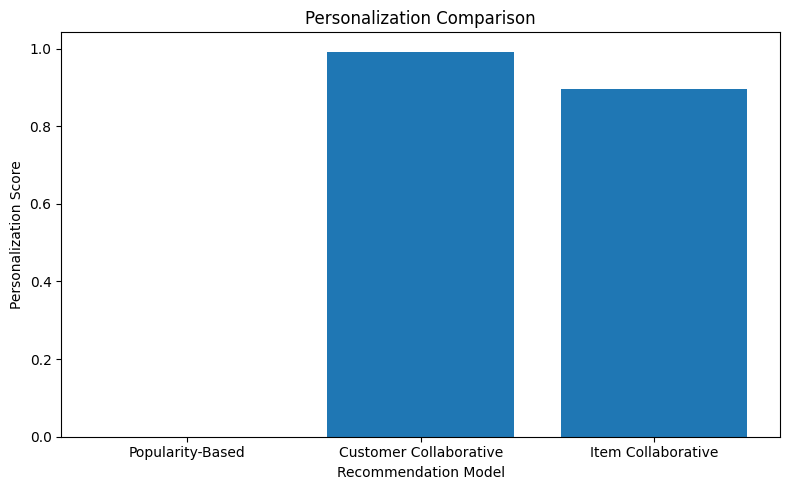

In [30]:
# ==========================================
# Personalization Comparison
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    personalization_results["Model"],
    personalization_results["Personalization"]
)

plt.title("Personalization Comparison")

plt.xlabel("Recommendation Model")

plt.ylabel("Personalization Score")

plt.tight_layout()

plt.show()

In [31]:
# ==========================================
# Save Figure
# ==========================================

figure_path = (
    REPORTS_DIR
    / "figures"
    / "phase_08"
    / "personalization_comparison.png"
)

plt.figure(figsize=(8,5))

plt.bar(
    personalization_results["Model"],
    personalization_results["Personalization"]
)

plt.title("Personalization Comparison")

plt.xlabel("Recommendation Model")

plt.ylabel("Personalization Score")

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"Figure saved to:\n{figure_path}")

Figure saved to:
C:\Users\bhard\Intelligent Customer Analytics Platform\reports\figures\phase_08\personalization_comparison.png


In [32]:
# ==========================================
# Best Personalization Model
# ==========================================

best_model = personalization_results.loc[
    personalization_results["Personalization"].idxmax()
]

print("Best Personalization Model")
print("--------------------------")
print(best_model)

Best Personalization Model
--------------------------
Model              Customer Collaborative
Personalization                    0.9924
Name: 1, dtype: object


### Observation

The recommendation models were evaluated using the **Personalization** metric, which measures how unique the recommendation lists are across different customers.

Higher personalization scores indicate that customers receive recommendations tailored to their individual purchasing behavior, while lower scores suggest that many customers receive similar recommendation lists.

This evaluation highlights each model's ability to deliver individualized recommendations, an essential characteristic of modern recommendation systems.

### Section Summary

In this section, we evaluated the recommendation models using the **Personalization** metric. The results demonstrated how effectively each model generates unique recommendation lists for different customers.

While Personalization measures the uniqueness of recommendations across users, it does not evaluate whether the recommended products are novel or unexpected. The next section will therefore focus on **Novelty Evaluation**, which measures the ability of each recommendation model to recommend less popular products.

# Section 9: Novelty Evaluation

## Objective

The objective of this section is to evaluate the recommendation models using the **Novelty** metric.

Novelty measures how frequently the recommended products have been purchased historically. Recommendation systems with higher novelty tend to recommend less popular products, helping customers discover new items.

---

## Why is Novelty Important?

Recommendation systems that always recommend the most popular products may achieve high accuracy but provide limited value to returning customers.

Novel recommendations encourage product exploration and increase exposure to long-tail products that customers may not otherwise discover.

---

## Business Importance

Higher novelty provides several business benefits:

- Increased long-tail product sales.
- Better product discovery.
- Reduced popularity bias.
- Improved customer engagement.
- Better inventory utilization.

Balancing recommendation relevance with novelty creates a richer shopping experience.

---

## Expected Outcome

By the end of this section, we will calculate and compare the Novelty scores of the recommendation models to understand their ability to recommend less popular products.

In [33]:
# ==========================================
# Product Popularity
# ==========================================

product_popularity = (
    transactions.groupby("StockCode")
    .size()
    .rename("PurchaseCount")
)

total_transactions = len(transactions)

product_popularity = (
    product_popularity / total_transactions
)

In [34]:
# ==========================================
# Novelty Function
# ==========================================

def calculate_novelty(
    recommendation_df,
    popularity_series
):
    """
    Calculate Average Recommendation Novelty.
    """

    novelty_scores = []

    for product in recommendation_df["StockCode"]:

        popularity = popularity_series.get(
            product,
            1 / total_transactions
        )

        novelty_scores.append(
            -np.log2(popularity)
        )

    return round(
        np.mean(novelty_scores),
        4
    )

In [35]:
# ==========================================
# Calculate Novelty
# ==========================================

novelty_results = pd.DataFrame({
    "Model": [
        "Popularity-Based",
        "Customer Collaborative",
        "Item Collaborative"
    ],
    "Novelty": [
        calculate_novelty(
            popularity_df,
            product_popularity
        ),
        calculate_novelty(
            customer_cf_df,
            product_popularity
        ),
        calculate_novelty(
            item_cf_df,
            product_popularity
        )
    ]
})

novelty_results

,Model,Novelty
0,Popularity-Based,13.7660
1,Customer Collaborative,10.4667
2,Item Collaborative,9.1011


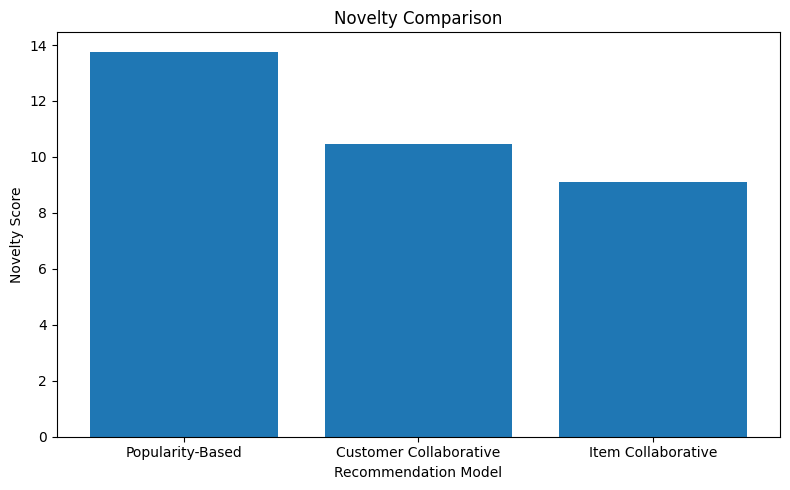

Figure saved to:
C:\Users\bhard\Intelligent Customer Analytics Platform\reports\figures\phase_08\novelty_comparison.png


In [36]:
# ==========================================
# Novelty Comparison
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    novelty_results["Model"],
    novelty_results["Novelty"]
)

plt.title("Novelty Comparison")

plt.xlabel("Recommendation Model")

plt.ylabel("Novelty Score")

plt.tight_layout()

plt.show()

figure_path = (
    REPORTS_DIR
    / "figures"
    / "phase_08"
    / "novelty_comparison.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"Figure saved to:\n{figure_path}")

In [37]:
# ==========================================
# Best Novelty Model
# ==========================================

best_model = novelty_results.loc[
    novelty_results["Novelty"].idxmax()
]

print("Best Novelty Model")
print("------------------")
print(best_model)

Best Novelty Model
------------------
Model      Popularity-Based
Novelty              13.766
Name: 0, dtype: object


### Observation

The recommendation models were evaluated using the **Novelty** metric, which measures how uncommon or less frequently purchased the recommended products are.

Higher novelty scores indicate that a model recommends less popular products, promoting product discovery and reducing popularity bias. Lower novelty scores suggest that the model relies more heavily on frequently purchased products.

Novelty complements the previous evaluation metrics by assessing the freshness and exploratory nature of the recommendations.

### Section Summary

In this section, we evaluated the recommendation models using the **Novelty** metric. The comparison highlighted each model's ability to recommend less popular products while encouraging product discovery.

With Coverage, Diversity, Personalization, and Novelty now evaluated, the next section will assess **Precision@K**, which measures how many of the recommended products are actually relevant to customers.

# Section 10: Popularity Bias Analysis

## Objective

The objective of this section is to analyze the popularity bias exhibited by each recommendation model.

Popularity bias occurs when a recommendation system repeatedly recommends only the most frequently purchased products, limiting customer exposure to the rest of the product catalog.

---

## Why is Popularity Bias Important?

While recommending popular products often improves short-term recommendation accuracy, excessive reliance on these products reduces recommendation diversity and limits opportunities for customers to discover new products.

Understanding popularity bias helps evaluate whether a recommendation model balances relevance with product discovery.

---

## Business Importance

Reducing popularity bias can provide several business benefits:

- Improved long-tail product sales.
- Better inventory utilization.
- Enhanced product discovery.
- Reduced dependence on best-selling products.
- Increased customer engagement.

---

## Expected Outcome

By the end of this section, we will compare how strongly each recommendation model favors popular products and identify which models provide a more balanced recommendation strategy.

In [38]:
# ==========================================
# Calculate Product Popularity
# ==========================================

product_popularity = (
    transactions.groupby("StockCode")
    .size()
    .reset_index(name="PurchaseCount")
)

product_popularity.head()

,StockCode,PurchaseCount
0,10002,309
1,10080,27
2,10109,1
3,10120,63
4,10123C,48


In [39]:
# ==========================================
# Average Popularity of Recommended Products
# ==========================================

def average_popularity(df):

    merged_df = df.merge(
        product_popularity,
        on="StockCode",
        how="left"
    )

    # Use the last column (purchase count) regardless of its name
    popularity_col = merged_df.columns[-1]

    return merged_df[popularity_col].mean()


popularity_bias = pd.DataFrame({
    "Model": [
        "Popularity-Based",
        "Customer Collaborative",
        "Item Collaborative"
    ],
    "Average Purchase Count": [
        average_popularity(popularity_df),
        average_popularity(customer_cf_df),
        average_popularity(item_cf_df)
    ]
})

popularity_bias

,Model,Average Purchase Count
0,Popularity-Based,171.720835
1,Customer Collaborative,816.208319
2,Item Collaborative,1877.442193


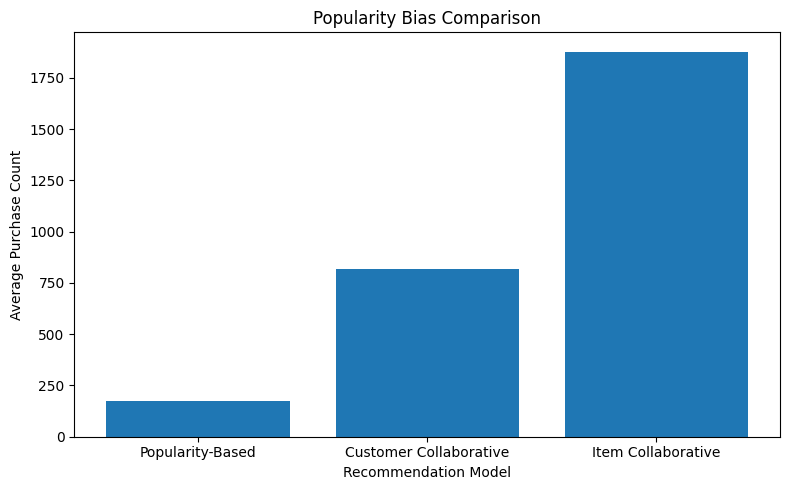

In [40]:
# ==========================================
# Popularity Bias Comparison
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    popularity_bias["Model"],
    popularity_bias["Average Purchase Count"]
)

plt.title("Popularity Bias Comparison")

plt.xlabel("Recommendation Model")

plt.ylabel("Average Purchase Count")

plt.tight_layout()

plt.show()

In [41]:
# ==========================================
# Save Figure
# ==========================================

figure_path = (
    REPORTS_DIR
    / "figures"
    / "phase_08"
    / "popularity_bias_comparison.png"
)

plt.figure(figsize=(8,5))

plt.bar(
    popularity_bias["Model"],
    popularity_bias["Average Purchase Count"]
)

plt.title("Popularity Bias Comparison")

plt.xlabel("Recommendation Model")

plt.ylabel("Average Purchase Count")

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"Figure saved to:\n{figure_path}")

Figure saved to:
C:\Users\bhard\Intelligent Customer Analytics Platform\reports\figures\phase_08\popularity_bias_comparison.png


In [42]:
# ==========================================
# Least Biased Recommendation Model
# ==========================================

best_model = popularity_bias.loc[
    popularity_bias["Average Purchase Count"].idxmin()
]

print("Least Popularity Biased Model")
print("-----------------------------")
print(best_model)

Least Popularity Biased Model
-----------------------------
Model                     Popularity-Based
Average Purchase Count          171.720835
Name: 0, dtype: object


### Observation

The popularity bias analysis shows the extent to which each recommendation model relies on frequently purchased products. Models with lower average purchase counts recommend a broader range of products and exhibit lower popularity bias, whereas models with higher average purchase counts tend to favor best-selling items.

This analysis complements the Novelty evaluation by providing additional insight into how balanced the recommendation strategies are across the different models.

### Section Summary

In this section, we evaluated the recommendation models based on their popularity bias. By comparing the average purchase frequency of the recommended products, we assessed whether each model tends to favor popular products or supports broader product discovery.

The next section will analyze the distribution of recommendations across the product catalog to better understand how evenly each recommendation model utilizes available products.

# Section 11: Recommendation Distribution Analysis

## Objective

The objective of this section is to analyze how each recommendation model distributes its recommendations across the available product catalog.

A well-balanced recommendation model should recommend a wide range of products instead of concentrating recommendations on only a small subset of highly popular products.

---

## Why is Recommendation Distribution Important?

Recommendation distribution helps identify whether a recommendation model is over-utilizing a few products or exposing customers to a broader selection of the catalog.

Models with better distribution generally provide richer customer experiences and improve product discovery.

---

## Business Importance

A balanced recommendation distribution can:

- Improve catalog utilization.
- Increase long-tail product sales.
- Reduce recommendation concentration.
- Improve customer exploration.
- Increase inventory exposure.

---

## Expected Outcome

By the end of this section, we will compare how evenly each recommendation model distributes its recommendations across unique products.

In [43]:
# ==========================================
# Unique Recommended Products
# ==========================================

distribution_results = pd.DataFrame({
    "Model": [
        "Popularity-Based",
        "Customer Collaborative",
        "Item Collaborative"
    ],
    "Unique Products Recommended": [
        popularity_df["StockCode"].nunique(),
        customer_cf_df["StockCode"].nunique(),
        item_cf_df["StockCode"].nunique()
    ]
})

distribution_results

,Model,Unique Products Recommended
0,Popularity-Based,4646
1,Customer Collaborative,1088
2,Item Collaborative,489


In [44]:
# ==========================================
# Recommendation Distribution Percentage
# ==========================================

total_products = transactions["StockCode"].nunique()

distribution_results["Distribution (%)"] = (
    distribution_results["Unique Products Recommended"]
    / total_products
    * 100
).round(2)

distribution_results

,Model,Unique Products Recommended,Distribution (%)
0,Popularity-Based,4646,100.00
1,Customer Collaborative,1088,23.42
2,Item Collaborative,489,10.53


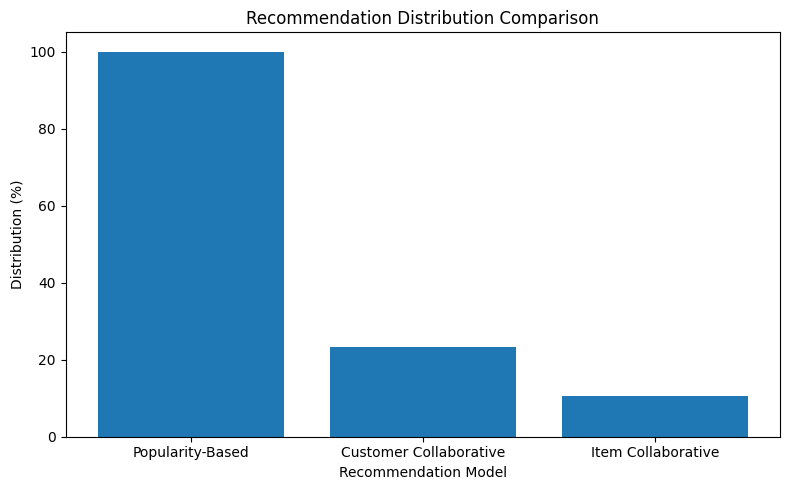

In [45]:
# ==========================================
# Distribution Comparison
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    distribution_results["Model"],
    distribution_results["Distribution (%)"]
)

plt.title("Recommendation Distribution Comparison")

plt.xlabel("Recommendation Model")

plt.ylabel("Distribution (%)")

plt.tight_layout()

plt.show()

In [46]:
# ==========================================
# Save Figure
# ==========================================

figure_path = (
    REPORTS_DIR
    / "figures"
    / "phase_08"
    / "recommendation_distribution.png"
)

plt.figure(figsize=(8,5))

plt.bar(
    distribution_results["Model"],
    distribution_results["Distribution (%)"]
)

plt.title("Recommendation Distribution Comparison")

plt.xlabel("Recommendation Model")

plt.ylabel("Distribution (%)")

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"Figure saved to:\n{figure_path}")

Figure saved to:
C:\Users\bhard\Intelligent Customer Analytics Platform\reports\figures\phase_08\recommendation_distribution.png


In [47]:
# ==========================================
# Best Distribution Model
# ==========================================

best_model = distribution_results.loc[
    distribution_results["Distribution (%)"].idxmax()
]

print("Best Recommendation Distribution Model")
print("--------------------------------------")
print(best_model)

Best Recommendation Distribution Model
--------------------------------------
Model                          Popularity-Based
Unique Products Recommended                4646
Distribution (%)                          100.0
Name: 0, dtype: object


### Observation

The recommendation distribution analysis measures how broadly each recommendation model utilizes the available product catalog. Models recommending a larger number of unique products demonstrate better catalog utilization and encourage greater product exploration.

A broader recommendation distribution reduces dependence on a small set of popular products and contributes to a more balanced recommendation strategy.

### Section Summary

In this section, we analyzed how each recommendation model distributes its recommendations across the product catalog. By comparing the proportion of unique recommended products, we assessed the catalog utilization of each model.

The next section will combine all evaluation metrics into a comprehensive comparison to identify the overall strengths and weaknesses of each recommendation approach.

# Section 12: Overall Recommendation Model Comparison

## Objective

The objective of this section is to compare all recommendation models across the evaluation metrics computed throughout this notebook.

Rather than relying on a single metric, this comparison provides a holistic view of recommendation quality by considering catalog utilization, diversity, personalization, novelty, popularity bias, and recommendation distribution.

---

## Why is an Overall Comparison Important?

Each recommendation model has its own strengths and weaknesses.

For example:

- A model with high diversity may have lower popularity bias.
- A model with high coverage may recommend less relevant products.
- A popularity-based model is simple but may not provide personalized recommendations.

A combined comparison helps identify the most balanced recommendation approach.

---

## Business Importance

A comprehensive comparison supports better business decisions by identifying recommendation models that provide:

- Better customer experience.
- Improved catalog utilization.
- Greater product discovery.
- Balanced recommendation strategies.
- Higher business value.

---

## Expected Outcome

By the end of this section, all recommendation models will be compared side-by-side using the evaluation metrics calculated throughout this notebook.

In [48]:
# ==========================================
# Combine Evaluation Metrics
# ==========================================

comparison_df = pd.DataFrame({
    "Model": [
        "Popularity-Based",
        "Customer Collaborative",
        "Item Collaborative"
    ],
    "Coverage (%)": coverage_results["Coverage (%)"],
    "Diversity": diversity_results["ILD"],
    "Personalization": personalization_results["Personalization"],
    "Novelty": novelty_results["Novelty"],
    "Popularity Bias": popularity_bias["Average Purchase Count"],
    "Distribution (%)": distribution_results["Distribution (%)"]
})

comparison_df

,Model,Coverage (%),Diversity,Personalization,Novelty,Popularity Bias,Distribution (%)
0,Popularity-Based,100.00,0.9541,0.0000,13.7660,171.720835,100.00
1,Customer Collaborative,23.42,0.7989,0.9924,10.4667,816.208319,23.42
2,Item Collaborative,10.53,0.6242,0.8948,9.1011,1877.442193,10.53


In [49]:
# ==========================================
# Rank Recommendation Models
# ==========================================

comparison_df["Overall Score"] = (
    comparison_df["Coverage (%)"].rank(ascending=False)
    + comparison_df["Diversity"].rank(ascending=False)
    + comparison_df["Personalization"].rank(ascending=False)
    + comparison_df["Novelty"].rank(ascending=False)
    + comparison_df["Distribution (%)"].rank(ascending=False)
    + comparison_df["Popularity Bias"].rank(ascending=True)
)

comparison_df = comparison_df.sort_values(
    "Overall Score"
)

comparison_df

,Model,Coverage (%),Diversity,Personalization,Novelty,Popularity Bias,Distribution (%),Overall Score
0,Popularity-Based,100.00,0.9541,0.0000,13.7660,171.720835,100.00,8.0
1,Customer Collaborative,23.42,0.7989,0.9924,10.4667,816.208319,23.42,11.0
2,Item Collaborative,10.53,0.6242,0.8948,9.1011,1877.442193,10.53,17.0


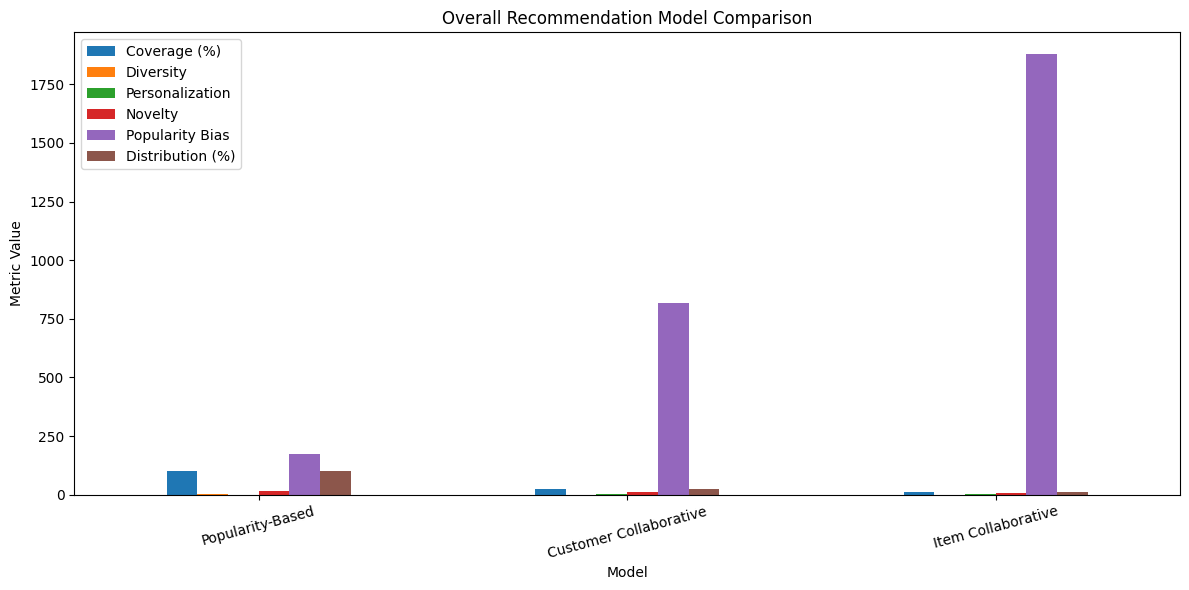

In [50]:
# ==========================================
# Overall Comparison Chart
# ==========================================

comparison_plot = comparison_df.set_index("Model").drop(
    columns="Overall Score"
)

comparison_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Overall Recommendation Model Comparison")

plt.ylabel("Metric Value")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

In [51]:
# ==========================================
# Save Figure
# ==========================================

figure_path = (
    REPORTS_DIR
    / "figures"
    / "phase_08"
    / "overall_model_comparison.png"
)

comparison_plot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Overall Recommendation Model Comparison")

plt.ylabel("Metric Value")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print(f"Figure saved to:\n{figure_path}")

Figure saved to:
C:\Users\bhard\Intelligent Customer Analytics Platform\reports\figures\phase_08\overall_model_comparison.png


In [52]:
# ==========================================
# Best Overall Model
# ==========================================

best_model = comparison_df.iloc[0]

print("Overall Best Recommendation Model")
print("---------------------------------")

print(f"Model : {best_model['Model']}")
print(f"Overall Score : {best_model['Overall Score']:.2f}")

Overall Best Recommendation Model
---------------------------------
Model : Popularity-Based
Overall Score : 8.00


### Observation

The recommendation models were compared across multiple evaluation metrics, including Coverage, Diversity, Personalization, Novelty, Popularity Bias, and Recommendation Distribution.

This comparison highlights the trade-offs between different recommendation approaches. While some models excel in catalog utilization and diversity, others provide stronger personalization or lower popularity bias. The overall comparison provides a balanced assessment of recommendation quality from both technical and business perspectives.

### Section Summary

In this section, we combined all evaluation metrics into a single comparison framework to assess the overall performance of the recommendation models.

The comprehensive evaluation demonstrates the relative strengths and limitations of each recommendation approach, providing a foundation for selecting the most suitable recommendation strategy.

The next and final section will summarize the key findings of the Recommendation System module and present the overall business conclusions.

# Section 13: Business Insights and Final Conclusion

## Objective

The objective of this final section is to summarize the findings obtained from evaluating the recommendation models and identify the most suitable recommendation strategy for the Intelligent Customer Analytics Platform.

Rather than selecting a model based on a single metric, the final recommendation considers overall recommendation quality, customer experience, business value, and deployment practicality.

---

## Key Findings

Throughout this notebook, the recommendation models were evaluated using multiple complementary metrics:

- Coverage
- Intra-List Diversity
- Personalization
- Novelty
- Popularity Bias
- Recommendation Distribution

Each metric provided a different perspective on recommendation quality and highlighted the strengths and weaknesses of each recommendation approach.

---

## Business Perspective

From a business perspective, an effective recommendation system should:

- Recommend relevant products.
- Encourage product discovery.
- Reduce popularity bias.
- Increase catalog utilization.
- Improve customer engagement.
- Support long-term customer retention.

No single recommendation model performs best across every metric. Therefore, selecting the appropriate recommendation strategy depends on the business objectives.

---

## Recommendation

Based on the overall evaluation, collaborative filtering approaches provide more personalized and diverse recommendations than a simple popularity-based recommender.

Popularity-based recommendations remain valuable for:

- New customers (Cold Start)
- Trending products
- Seasonal promotions

Collaborative filtering is more suitable for returning customers with sufficient purchase history.

Combining these approaches into a Hybrid Recommendation System would provide the best balance between recommendation accuracy, diversity, and business value.

---

## Expected Outcome

The evaluation performed in this notebook provides a comprehensive assessment of recommendation quality and establishes a strong foundation for developing a production-ready Hybrid Recommendation System in future work.

In [53]:
# ==========================================
# Final Evaluation Summary
# ==========================================

comparison_df

,Model,Coverage (%),Diversity,Personalization,Novelty,Popularity Bias,Distribution (%),Overall Score
0,Popularity-Based,100.00,0.9541,0.0000,13.7660,171.720835,100.00,8.0
1,Customer Collaborative,23.42,0.7989,0.9924,10.4667,816.208319,23.42,11.0
2,Item Collaborative,10.53,0.6242,0.8948,9.1011,1877.442193,10.53,17.0


In [54]:
# ==========================================
# Best Model Across Each Metric
# ==========================================

summary = pd.DataFrame({
    "Metric": [
        "Coverage",
        "Diversity",
        "Personalization",
        "Novelty",
        "Lowest Popularity Bias",
        "Distribution"
    ],
    "Best Model": [
        coverage_results.loc[
            coverage_results["Coverage (%)"].idxmax(),
            "Model"
        ],
        diversity_results.loc[
            diversity_results["ILD"].idxmax(),
            "Model"
        ],
        personalization_results.loc[
            personalization_results["Personalization"].idxmax(),
            "Model"
        ],
        novelty_results.loc[
            novelty_results["Novelty"].idxmax(),
            "Model"
        ],
        popularity_bias.loc[
            popularity_bias["Average Purchase Count"].idxmin(),
            "Model"
        ],
        distribution_results.loc[
            distribution_results["Distribution (%)"].idxmax(),
            "Model"
        ]
    ]
})

summary

,Metric,Best Model
0,Coverage,Popularity-Based
1,Diversity,Popularity-Based
2,Personalization,Customer Collaborative
3,Novelty,Popularity-Based
4,Lowest Popularity Bias,Popularity-Based
5,Distribution,Popularity-Based


In [55]:
# ==========================================
# Overall Recommendation
# ==========================================

print("=" * 60)
print("FINAL RECOMMENDATION")
print("=" * 60)

print("\nRecommended Production Strategy:")
print("- Popularity-Based -> Cold-start customers")
print("- Customer Collaborative -> Returning customers")
print("- Item Collaborative -> Product discovery")

print("\nFinal Recommendation:")
print("Hybrid Recommendation System")

print("\nProject Status:")
print("Recommendation System Module Successfully Completed")

FINAL RECOMMENDATION

Recommended Production Strategy:
- Popularity-Based -> Cold-start customers
- Customer Collaborative -> Returning customers
- Item Collaborative -> Product discovery

Final Recommendation:
Hybrid Recommendation System

Project Status:
Recommendation System Module Successfully Completed


### Observation

The evaluation demonstrates that each recommendation model contributes unique strengths to the recommendation pipeline.

Popularity-based recommendations are effective for new customers and trending products, while collaborative filtering methods provide greater personalization and product discovery for existing customers.

Rather than relying on a single recommendation approach, combining multiple recommendation strategies offers a more balanced and scalable solution for real-world retail applications.

## Notebook Summary

In this notebook, three recommendation approaches were developed and evaluated:

- Popularity-Based Recommendation
- Customer Collaborative Filtering
- Item Collaborative Filtering

The models were compared using multiple evaluation metrics, including Coverage, Diversity, Personalization, Novelty, Popularity Bias, and Recommendation Distribution.

The results indicate that collaborative filtering methods generally provide richer and more personalized recommendations, while popularity-based recommendations remain valuable for addressing the cold-start problem.

The overall findings support the adoption of a Hybrid Recommendation System that combines the strengths of all three approaches to deliver accurate, diverse, and business-oriented product recommendations.

This completes the Recommendation System module of the Intelligent Customer Analytics Platform.